# ternary_colormap.jl

Blending three corner colours by a three-component composition, à la `tricolore` / `pyrolite`.
Makie colormaps are scalar → colour, so a `TernaryColormap` is a callable you broadcast, not a `colormap` argument.

In [1]:
include("../scripts/ternary_colormap.jl")
using .TernaryColormaps

using CairoMakie
CairoMakie.activate!()

## Applying it

Inputs are normalised, so counts work as well as fractions.

In [30]:
cm = TernaryColormap()

# corner 1, corner 2, corner 3, the neutral centre, and unnormalised counts
xx = [cm(1, 0, 0), cm(0, 1, 0), cm(0, 0, 1), cm(1, 1, 1), cm([2, 3, 5])];

In [31]:
display(xx)

In [32]:
# an N x 3 matrix of rows, or broadcast over three separate arrays
w3 = [0.7 0.2 0.1; 0.1 0.8 0.1; 1/3 1/3 1/3]

cm(w3) == cm.(w3[:, 1], w3[:, 2], w3[:, 3])

true

## The legend

`ternary_legend` makes a figure, `ternary_legend!` draws into a grid position or an existing axis and returns the axis.

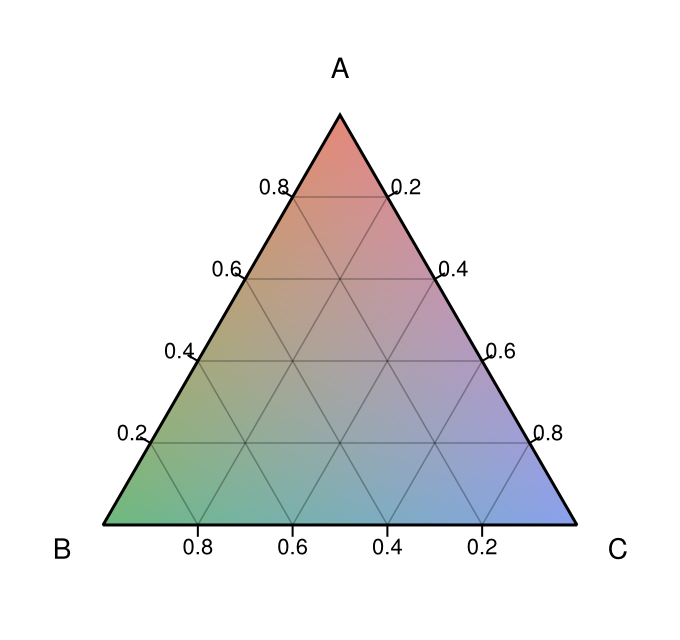

In [33]:
ternary_legend(cm; labels=("A", "B", "C"), figure=(size=(340, 320),))

## Corner colours

Any Makie colour spec works. `balanced_corners` generates the equal-lightness, equal-chroma, 120°-apart triple that `tricolore` uses.

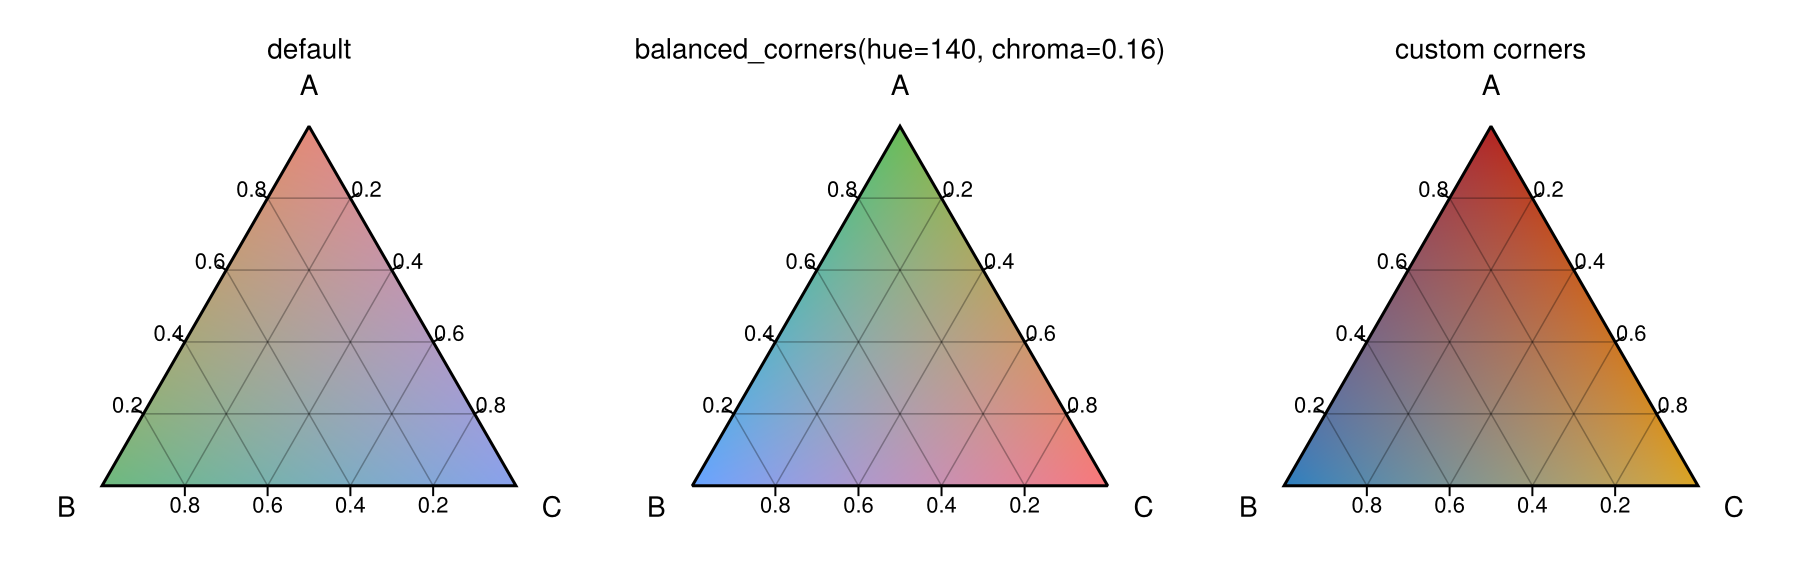

In [5]:
let fig = Figure(size=(900, 290))
    maps = [
        TernaryColormap() => "default",
        TernaryColormap(balanced_corners(; hue=140, chroma=0.16)...) => "balanced_corners(hue=140, chroma=0.16)",
        TernaryColormap(:firebrick, "#2a7fbf", :goldenrod) => "custom corners",
    ]
    for (i, (m, lab)) in enumerate(maps)
        ternary_legend!(fig[1, i], m; labels=("A", "B", "C"))
        Label(fig[1, i, Top()], lab)
    end
    fig
end

## Mixing space

Same three corners, blended in each available space. `:lab` is what `tricolore` does, `:srgb` what `pyrolite` does.

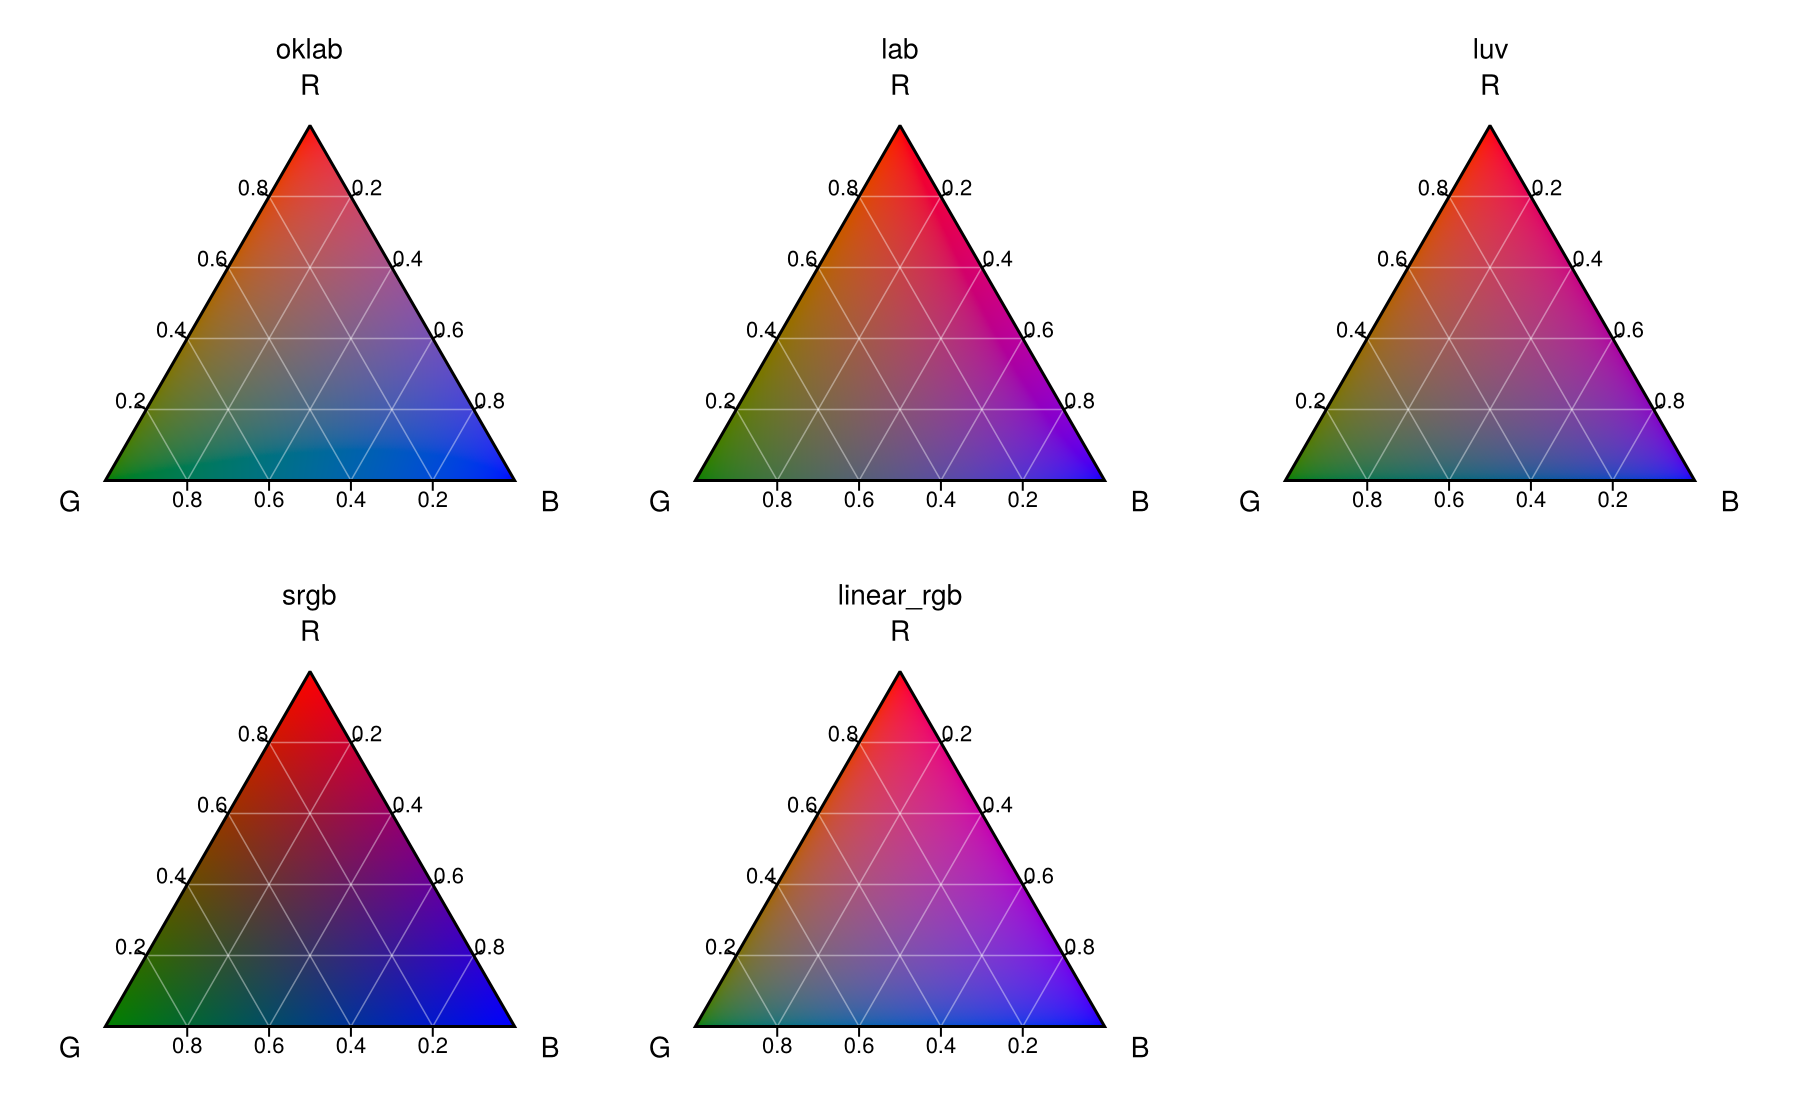

In [6]:
let fig = Figure(size=(900, 560))
    for (i, s) in enumerate(TernaryColormaps.MIXING_SPACES)
        r, c = fldmod1(i, 3)
        ternary_legend!(fig[r, c], TernaryColormap(:red, :green, :blue; space=s);
            labels=("R", "G", "B"), gridcolor=(:white, 0.4))
        Label(fig[r, c, Top()], string(s))
    end
    fig
end

## Stretching the blend

`power` sharpens (`> 1`) or flattens (`< 1`) towards the corners, `saturation` scales the distance from the neutral centre, `center` moves which composition is neutral.

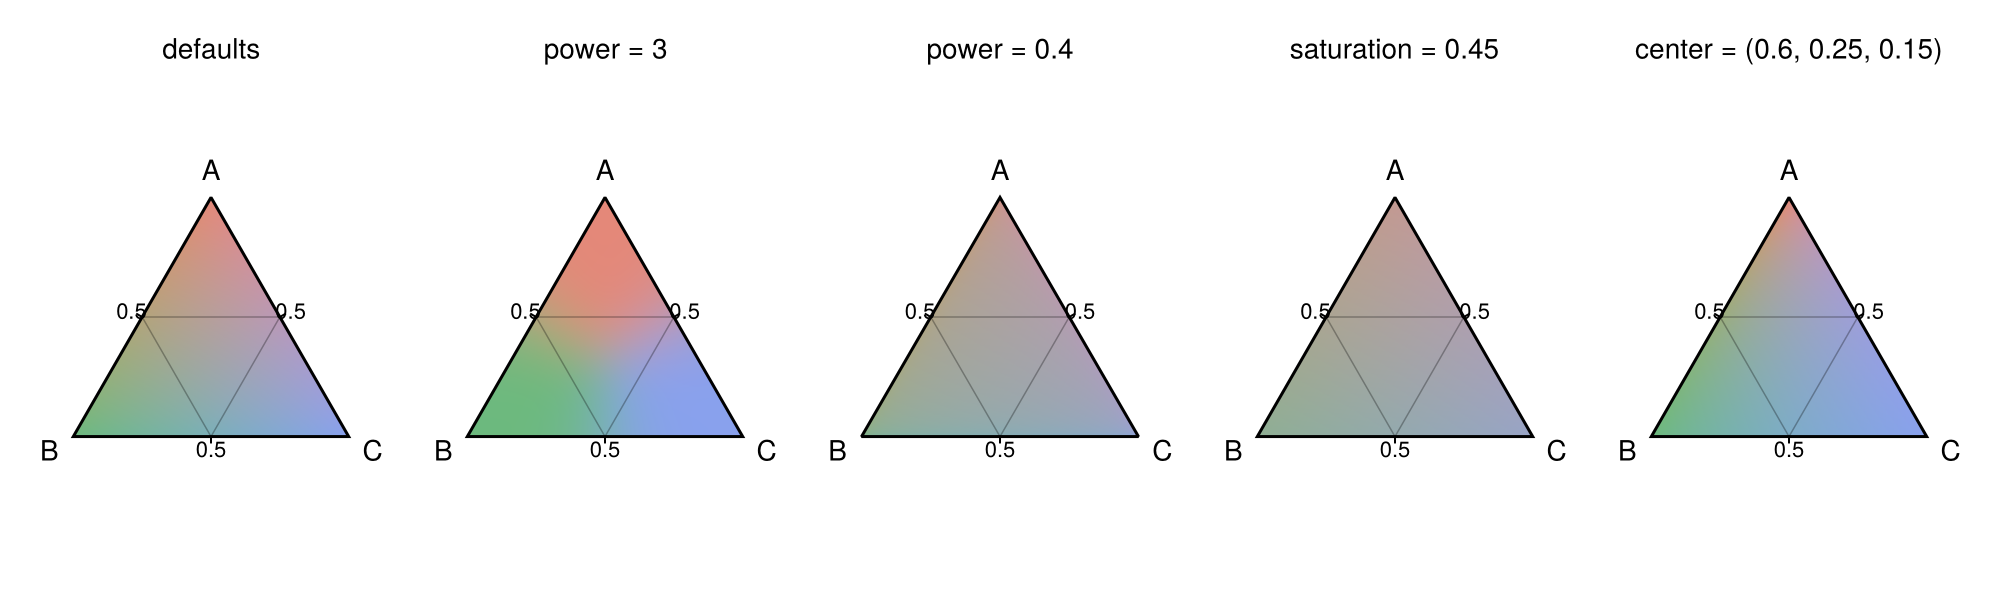

In [7]:
let fig = Figure(size=(1000, 300))
    opts = [
        (;) => "defaults",
        (; power=3) => "power = 3",
        (; power=0.4) => "power = 0.4",
        (; saturation=0.45) => "saturation = 0.45",
        (; center=(0.6, 0.25, 0.15)) => "center = (0.6, 0.25, 0.15)",
    ]
    for (i, (kw, lab)) in enumerate(opts)
        ternary_legend!(fig[1, i], TernaryColormap(; kw...); labels=("A", "B", "C"), ticks=[0.5])
        Label(fig[1, i, Top()], lab)
    end
    fig
end

## Discrete bins

`nbins` snaps to flat patches instead of a smooth fill (`tricolore`'s `breaks`). Bins are coloured by their centroid.

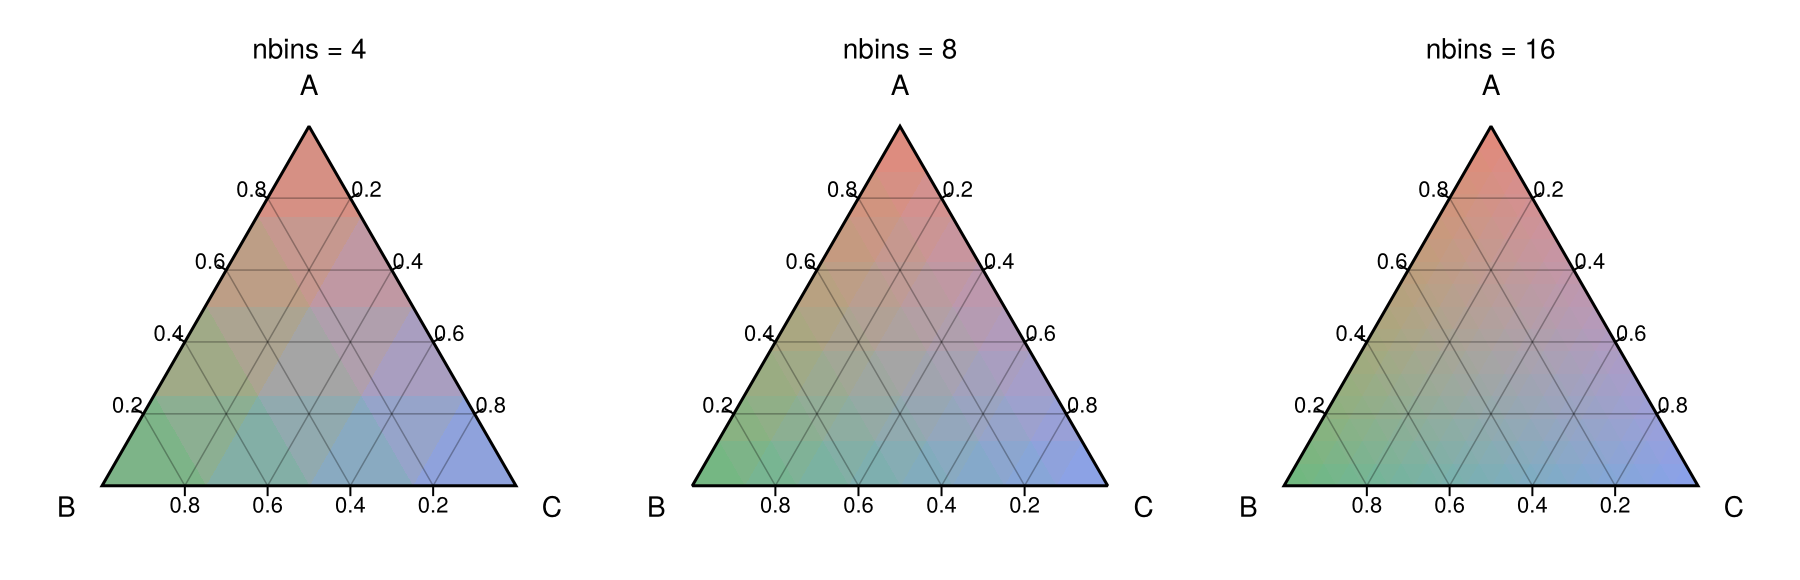

In [8]:
let fig = Figure(size=(900, 290))
    for (i, n) in enumerate((4, 8, 16))
        ternary_legend!(fig[1, i], cm; nbins=n, labels=("A", "B", "C"))
        Label(fig[1, i, Top()], "nbins = $n")
    end
    fig
end

## Legend styling

Everything drawn is a keyword. `ticks` and `tickformat` take one value for all three axes or a 3-tuple for per-axis control. Full list in `?ternary_legend!`.

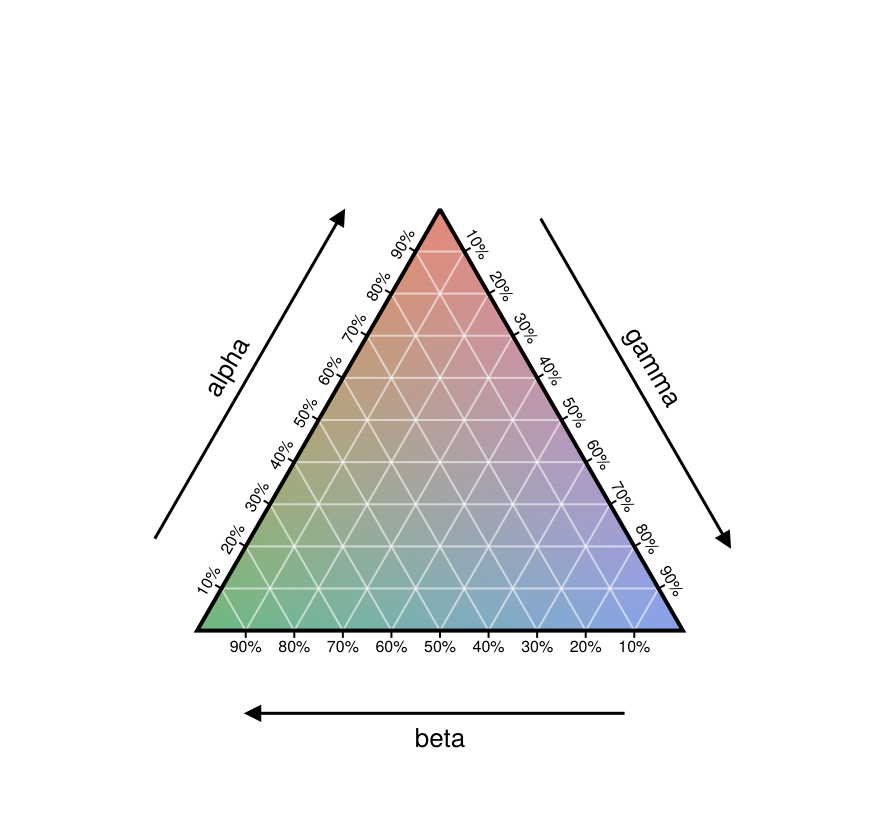

In [9]:
ternary_legend(cm;
    figure=(size=(440, 420),),
    labels=("alpha", "beta", "gamma"),
    labelsvisible=false,            # corner labels off, arrow labels instead
    arrowsvisible=true, arrowoffset=0.17, arrowlabelsize=13,
    ticks=0.1:0.1:0.9,
    tickformat=t -> string(round(Int, 100t), "%"),
    ticklabelrotation=:parallel, ticklabelsize=8, ticklabeloffset=0.032,
    ticklength=0.015,
    gridcolor=(:white, 0.55), gridwidth=1.0,
    framewidth=2,
    padding=0.34,
)

## Colouring data

`ternary_legend!` returns the axis, and `bary2cart` places compositions on it, so the data can be shown on its own legend.

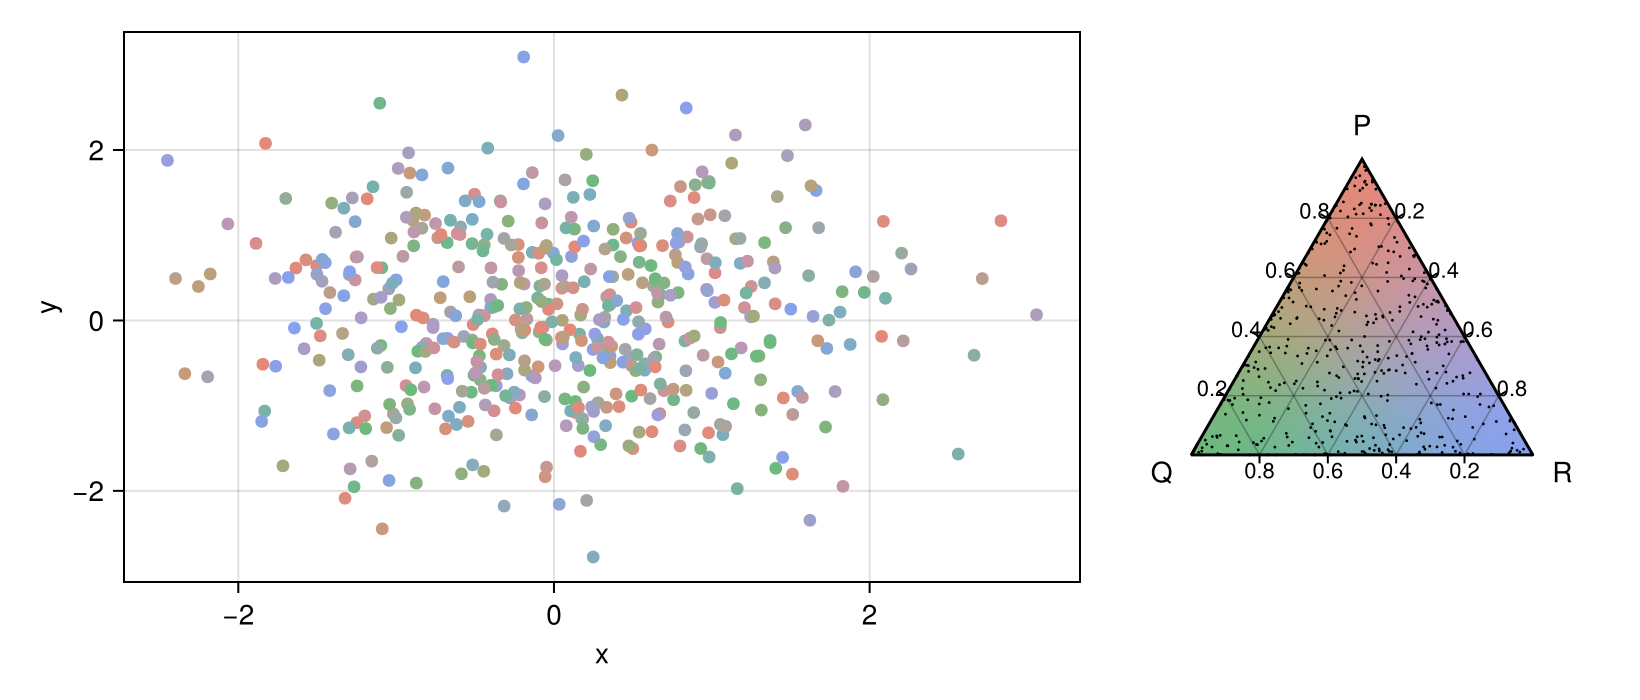

In [10]:
using Random
Random.seed!(0)

n = 500
w = rand(n, 3) .^ 2
w ./= sum(w; dims=2)
x, y = randn(n), randn(n)

datacm = TernaryColormap(; power=1.5)

let fig = Figure(size=(820, 350))
    ax = Axis(fig[1, 1]; xlabel="x", ylabel="y")
    scatter!(ax, x, y; color=datacm(w), markersize=9)

    lax = ternary_legend!(fig[1, 2], datacm; labels=("P", "Q", "R"), padding=0.22)
    scatter!(lax, bary2cart.(eachrow(w)); color=:black, markersize=2)

    colsize!(fig.layout, 2, Relative(0.34))
    fig
end